In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

def _find_repo_root(start_path):
    start_path = Path(start_path).resolve()
    for folder in (start_path, *start_path.parents):
        if (folder / "A001_functions").exists() and (folder / "C001_Mesh_files").exists():
            return folder
    return start_path


REPO_ROOT = _find_repo_root(Path.cwd())
MESH_FILES_DIR = REPO_ROOT / "C001_Mesh_files"

repo_root_str = str(REPO_ROOT)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)

from A001_functions.plot_mesh_functions import (
    plot_graph_json_with_source,
    plot_graph_mesh,
    plot_mesh_json,
    plot_mesh_json_periodic,
)


def resolve_mesh_file_path(mesh_file_path):
    mesh_file_path = Path(mesh_file_path).expanduser()
    if mesh_file_path.is_absolute():
        return mesh_file_path

    candidates = [
        Path.cwd() / mesh_file_path,
        REPO_ROOT / mesh_file_path,
        MESH_FILES_DIR / mesh_file_path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    if mesh_file_path.parts and mesh_file_path.parts[0] == "C001_Mesh_files":
        return REPO_ROOT / mesh_file_path
    return MESH_FILES_DIR / mesh_file_path


def _has_periodic_pairs(mesh_file_path):
    with open(mesh_file_path, "r") as f:
        payload = json.load(f)

    periodic = payload.get("periodic", {})
    return bool(
        periodic.get("left_right_pairs")
        or periodic.get("top_bottom_pairs")
    )


def plot_mesh_file(
    mesh_file_path,
    *,
    show_periodic_matching=True,
    overlay_source_mesh=True,
    boundary_only=False,
    show_nodes_graph=True,
    show=True,
):
    """Plot any JSON mesh artifact by detecting its extension.

    Supported files:
    - .mesh.json: finite-element mesh plus node-label plots; if periodic
      matching exists, also plots the stored periodic node pairs.
    - .graph.json: Voronoi graph, optionally over the saved source mesh.
    - .grid.json: Cartesian grid, optionally over the saved source mesh.
    - .gridhex.json: hexagonal grid, optionally over the saved source mesh.
    """
    mesh_file_path = resolve_mesh_file_path(mesh_file_path)
    mesh_file_path_str = str(mesh_file_path)
    figures = []

    if mesh_file_path_str.endswith(".mesh.json"):
        figures.extend(plot_mesh_json(mesh_file_path_str, show=False))
        if show_periodic_matching and _has_periodic_pairs(mesh_file_path):
            figures.append(plot_mesh_json_periodic(mesh_file_path_str, show=False))

    elif mesh_file_path_str.endswith((".graph.json", ".grid.json", ".gridhex.json")):
        if overlay_source_mesh:
            with open(mesh_file_path, "r") as f:
                graph_payload = json.load(f)
            source_mesh_path = graph_payload.get("source_mesh_path")
            source_mesh_path = (
                str(resolve_mesh_file_path(source_mesh_path))
                if source_mesh_path else None
            )
            figures.append(
                plot_graph_json_with_source(
                    mesh_file_path_str,
                    source_mesh_path=source_mesh_path,
                    overlay_mesh=True,
                    boundary_only=boundary_only,
                    show_nodes_graph=show_nodes_graph,
                    show=False,
                )
            )
        else:
            figures.append(
                plot_graph_mesh(
                    mesh_file_path_str,
                    show_nodes=show_nodes_graph,
                    show=False,
                )
            )

    else:
        raise ValueError(
            "Unsupported mesh extension. Use .mesh.json, .graph.json, "
            ".grid.json, or .gridhex.json."
        )

    if show:
        plt.show()

    return figures


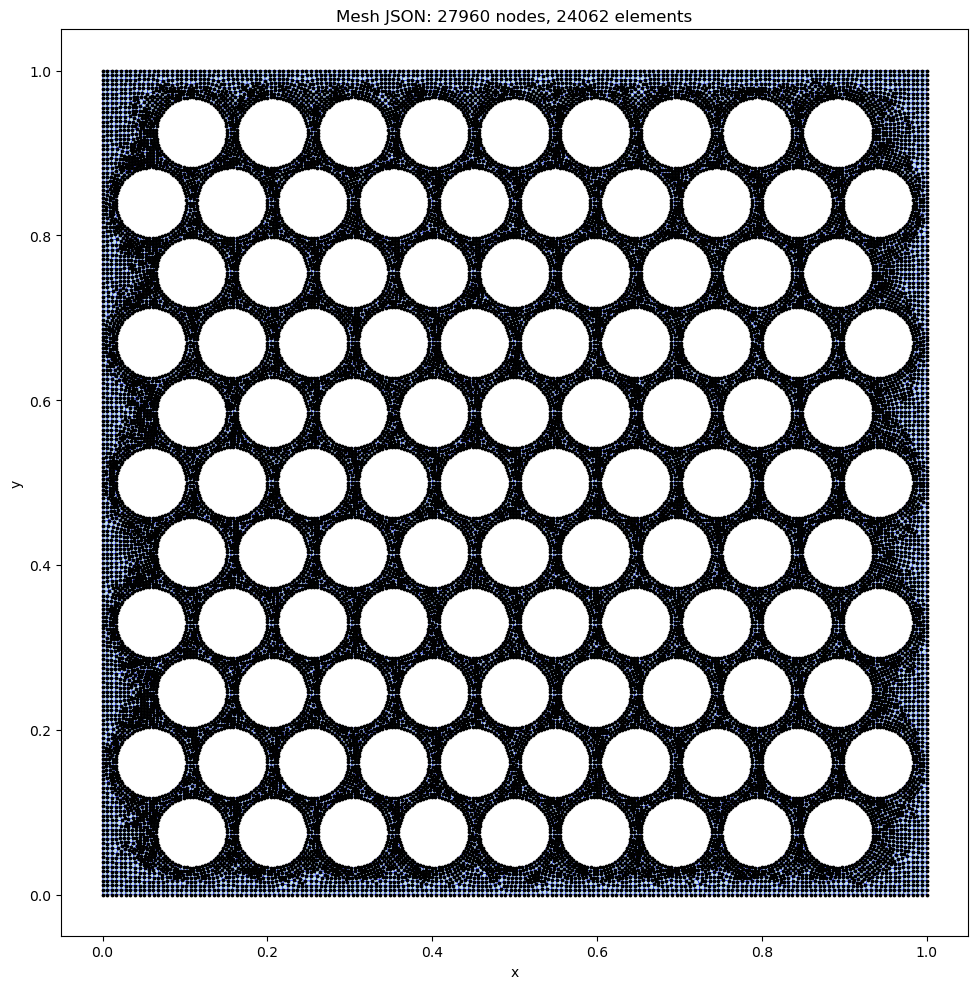

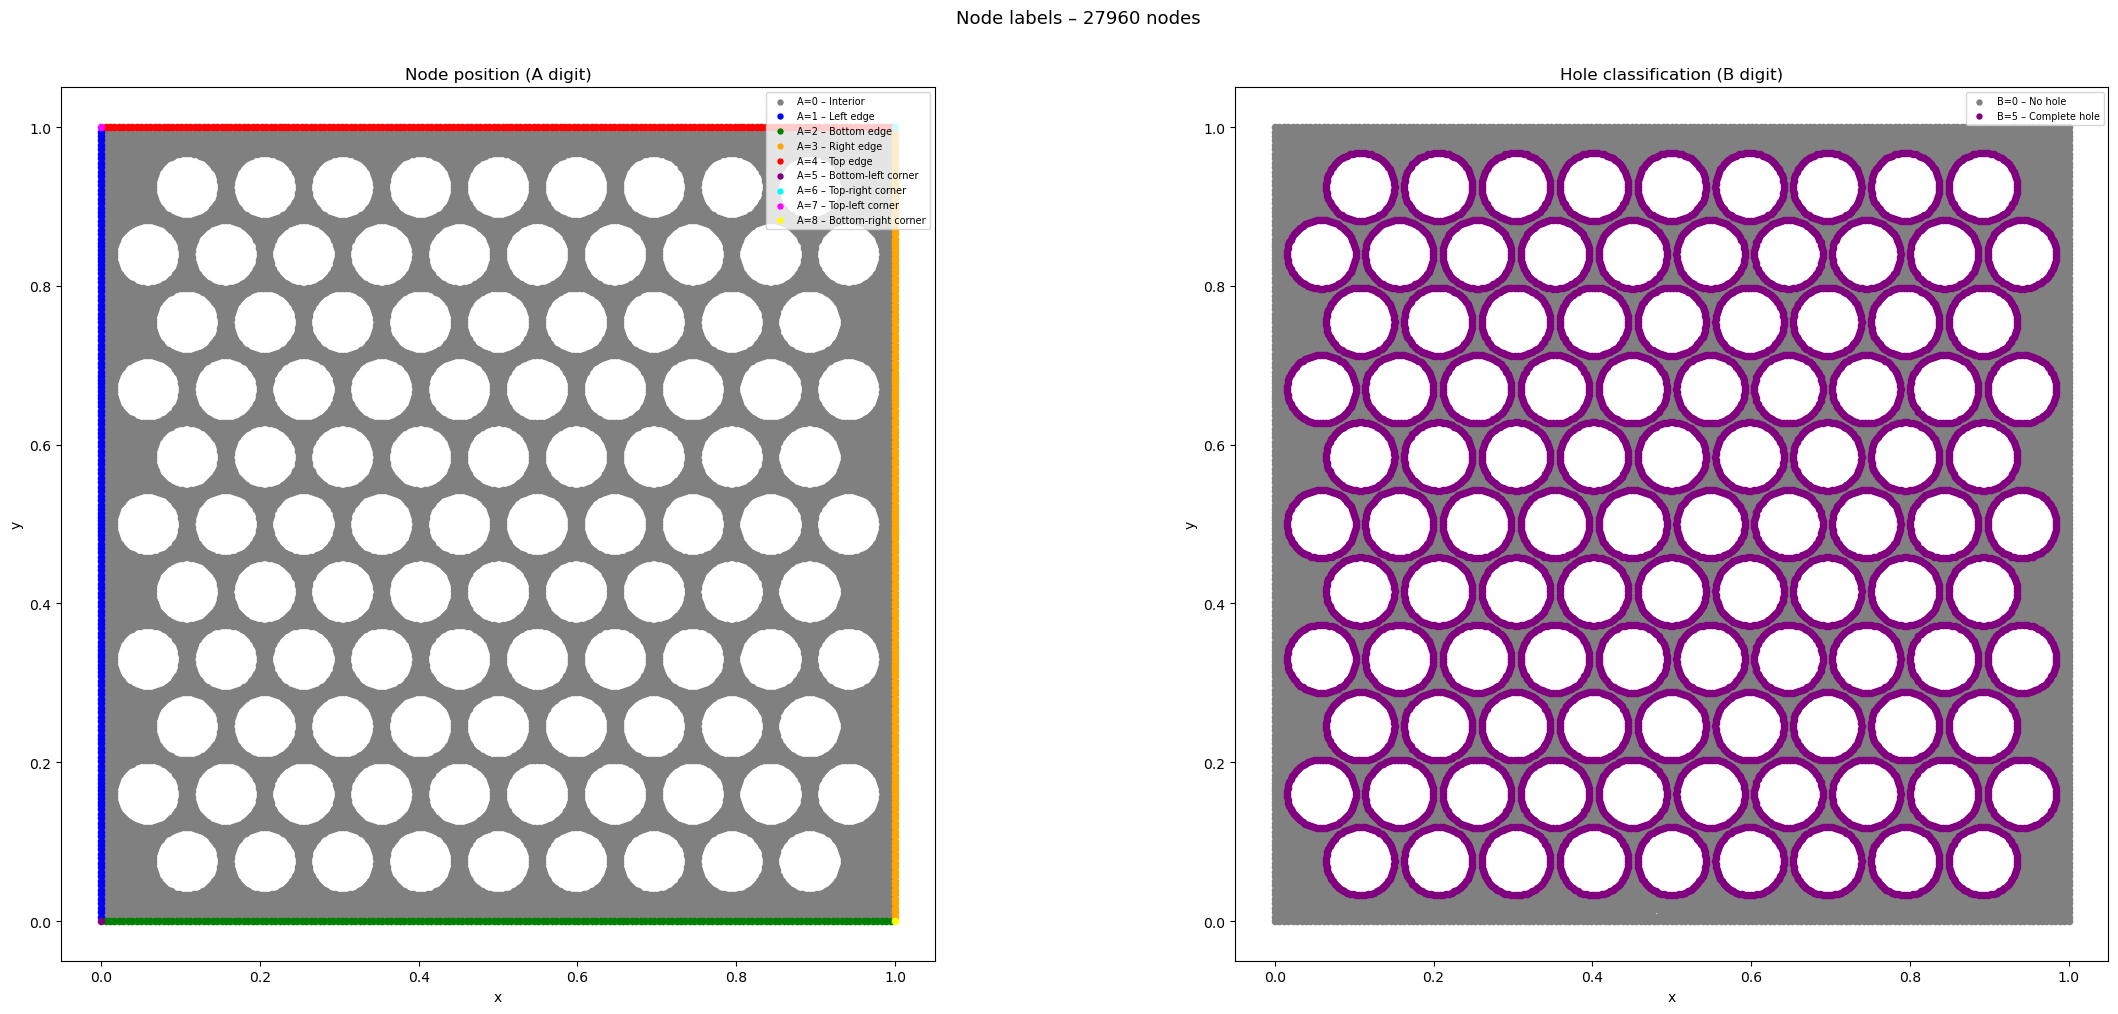

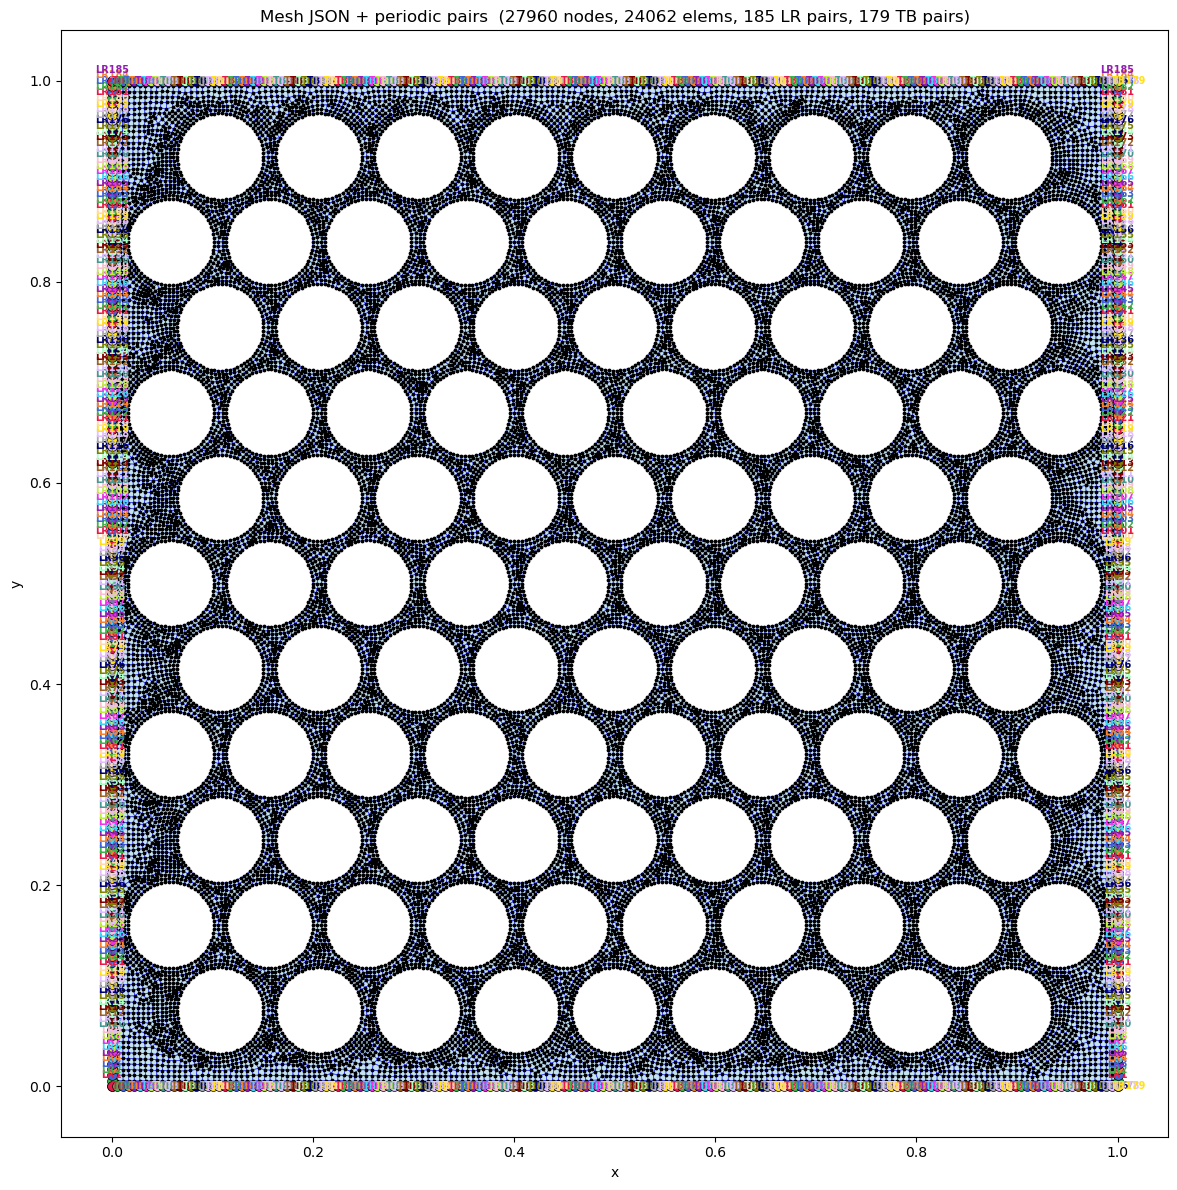

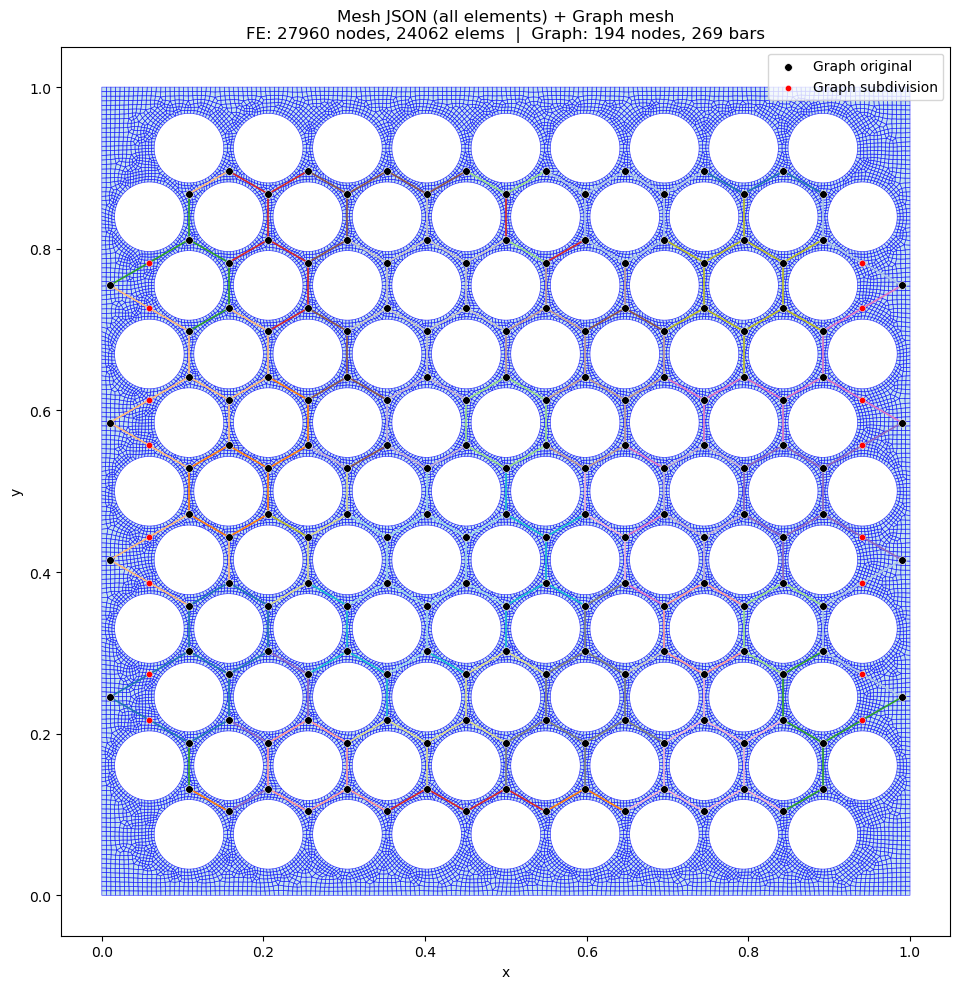

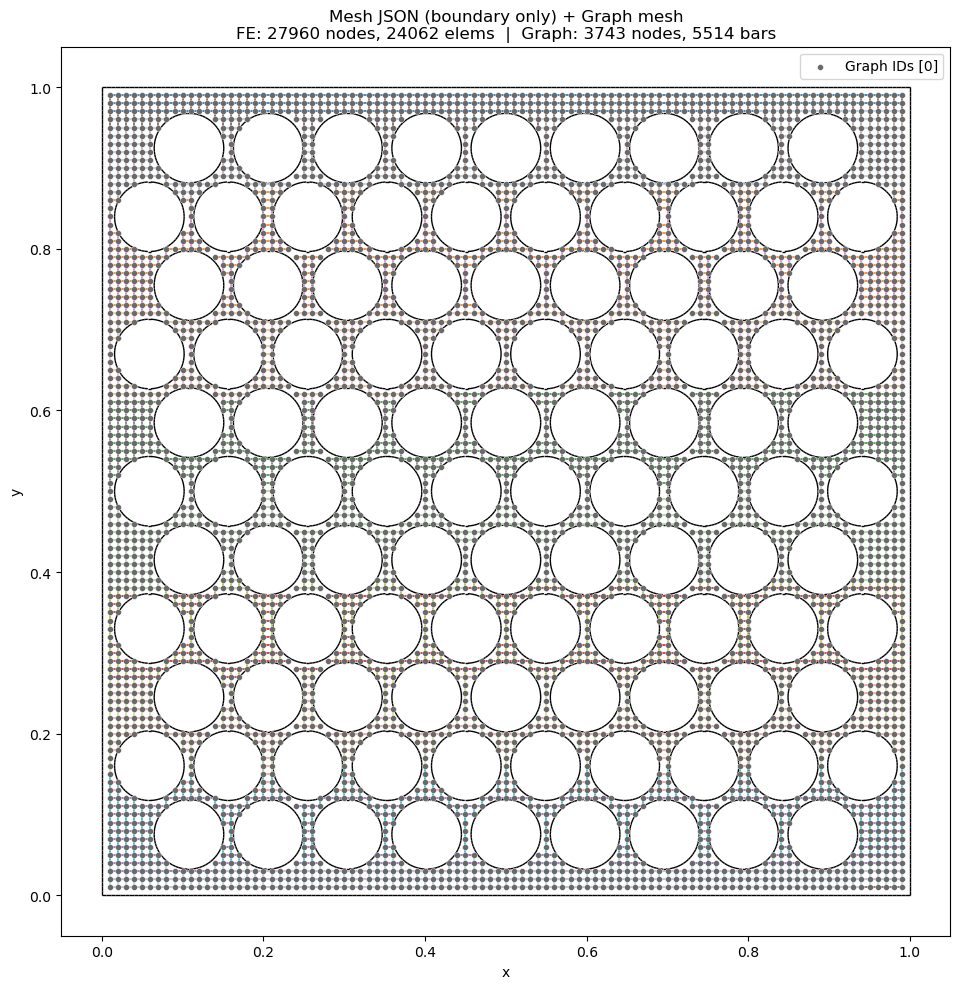

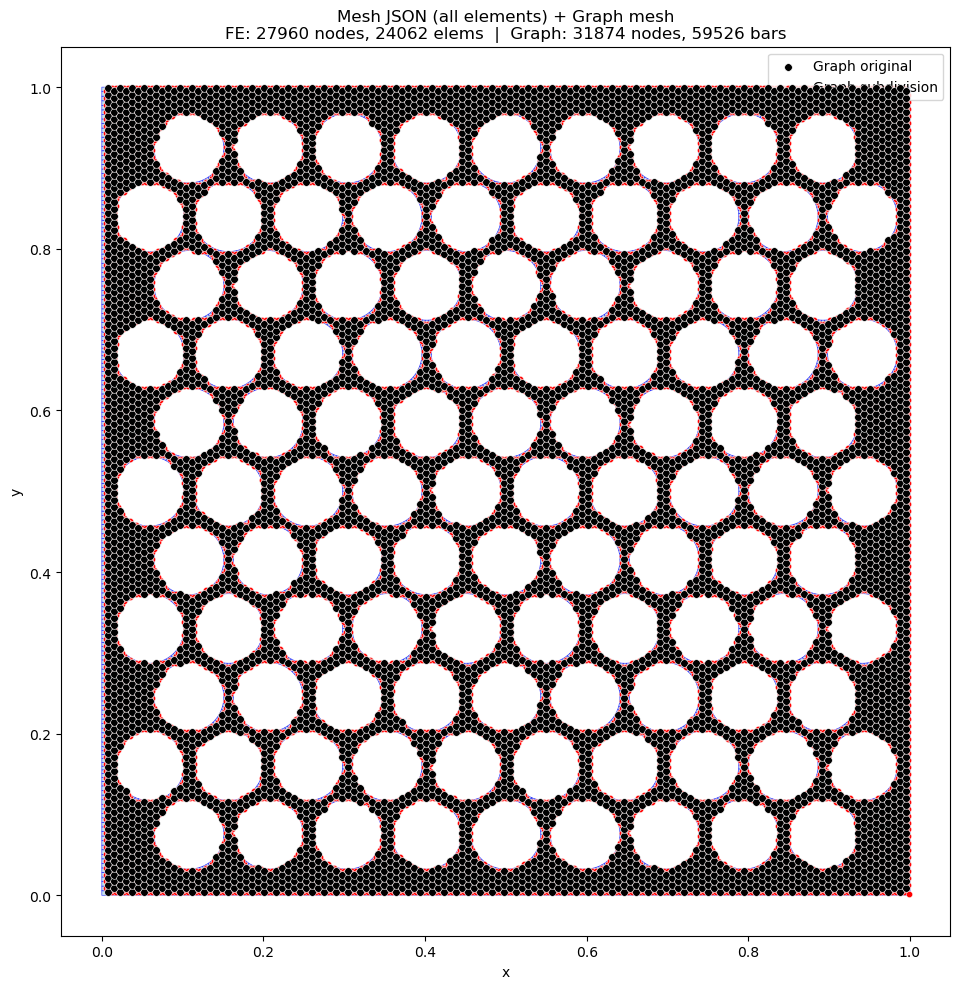

[<Figure size 1000x1000 with 1 Axes>]

In [2]:
# Examples:
plot_mesh_file("A3000_hexagonal_mesh.mesh.json")
plot_mesh_file("A3000_G2000.graph.json")
plot_mesh_file("A3000_H2002.grid.json", boundary_only=True)
plot_mesh_file("A3000_I2003.gridhex.json")
